# 1-Dimensional Chebyshev Polynomials in Julia

Notebook with basics on the `BasisMatrices.jl` package to contruct Chebyshev polynomial approximations

In [2]:
using BasisMatrices

### Setting up a Basis structure

In [3]:
x = range(-2.0, 2.0, length = 6)

-2.0:0.8:2.0

In [4]:
basis = Basis(ChebParams(length(x), minimum(x), maximum(x)))

1 dimensional Basis on the hypercube formed by (-2.0,) × (2.0,).
Basis families are Cheb


In [5]:
typeof(basis)

Basis{1,Tuple{ChebParams{Float64}}}

The fields for the `Basis()` method depend on the type of polynomial. For a Chebyshev polynomial, it needs to know the number of points - `len(x)` - and the lower and upper endpoints - `minimum(x)` and `maximum(x)`

Now that we have constructed our basis type we can extract the interpolation nodes that were computed. To do this, simply use the `nodes` method:

In [6]:
S, xgrid = nodes(basis);

Here `S` gives you the tensor product - this is there because the package supports multidimensional interpolation - for now think of it like `xgrid` which gives you the vector of nodes for each dimension of it's own

### Using the BasisMatrix

Suppose we want to approximate the function $f(x) = sin(x)$ using our basis defined above. Create a `BasisMatrix` object - this allows us to evaluate the basis functions at the desired points - pass the `Expanded()` argument because this is the easiest way to back out the coefficients - although not the most efficient

In [15]:
Φ = BasisMatrix(basis, Expanded(), S, 0)
Φ.vals[1]

6×6 Array{Float64,2}:
 1.0  -0.965926   0.866025     -0.707107   0.5  -0.258819
 1.0  -0.707107   2.22045e-16   0.707107  -1.0   0.707107
 1.0  -0.258819  -0.866025      0.707107   0.5  -0.965926
 1.0   0.258819  -0.866025     -0.707107   0.5   0.965926
 1.0   0.707107  -2.22045e-16  -0.707107  -1.0  -0.707107
 1.0   0.965926   0.866025      0.707107   0.5   0.258819

In [15]:
Φ₂ = BasisMatrix(basis, Direct(), [x[1]]).vals[1]

1×6 Array{Float64,2}:
 1.0  -1.0  1.0  -1.0  1.0  -1.0

In [17]:
Φ₃ = BasisMatrix(basis, Tensor())
Φ₃.vals[1]

6×6 Array{Float64,2}:
 1.0  -0.965926   0.866025     -0.707107   0.5  -0.258819
 1.0  -0.707107   2.22045e-16   0.707107  -1.0   0.707107
 1.0  -0.258819  -0.866025      0.707107   0.5  -0.965926
 1.0   0.258819  -0.866025     -0.707107   0.5   0.965926
 1.0   0.707107  -2.22045e-16  -0.707107  -1.0  -0.707107
 1.0   0.965926   0.866025      0.707107   0.5   0.258819

Think of $\Phi$ as the following matrix:
$$ \begin{pmatrix} T_0(x_0) & T_1(x_0) & \dots & T_{n-1}(x_0)  \\ 
T_0(x_1) & T_1(x_1) & \dots & T_{n-1}(x_1) \\
\vdots & \vdots & \vdots & \vdots \\
T_0 (x_{n-1}) & T_1(x_{n-1}) & \dots & T_{n-1}(x_{n-1})  \end{pmatrix}  $$

where each $T_i$ is the Chebyshev polynomial of order $i$. Note that this representation uses a different basis than Python's `chebval.chebvander`, so evaluating by hand requires care.

In [21]:
# Actual function at interpolation nodes:
f(x) = sin.(x)
y = f(S)

# Solve linear system to get the coefficients:
q = Φ.vals[1] \ y

6-element Array{Float64,1}:
  0.0                   
  1.1534496613004537    
  3.204937810639273e-17 
 -0.25789148363423775   
  4.6259292692714846e-18
  0.01442914766147458   

In [22]:
q₂ = Φ₃.vals[1] \ y

6-element Array{Float64,1}:
  0.0                   
  1.1534496613004537    
  3.204937810639273e-17 
 -0.25789148363423775   
  4.6259292692714846e-18
  0.01442914766147458   

Now that we have our coefficients, we use `funeval` which uses kronecker products to go back to the original basis

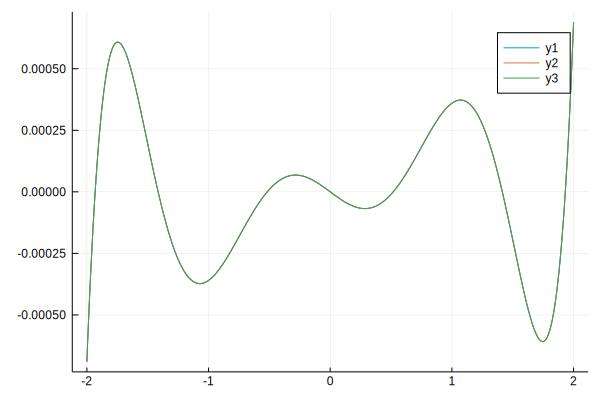

In [28]:
x_dense = range(-2, 2, length = 1000)
ye = funeval(q, basis, x_dense)

# Alternative method - pass the new grid to BasisMatrix and construct a new matrix 
bme2 = BasisMatrix(basis, Direct(), x_dense)
ye2 = bme2.vals[1]*q

#bme2 = BasisMatrix(basis, Tensor(), [x_dense])
ye3 = bme2.vals[1]*q

# plot to see how it does
using Plots
plot(x_dense, ye - f.(x_dense))
plot!(x_dense, ye2 - f.(x_dense))
plot!(x_dense, ye3 - f.(x_dense))

For a discussion on how to interpolate and some examples see the docs [here](https://github.com/QuantEcon/BasisMatrices.jl/blob/master/demo/basis_mat_formats.jl)